# Extracción de Características y Modelamiento
## Predicción de demanda energética en Colombia 2024–2025
---
Este notebook desarrolla el pipeline completo de modelamiento para predecir la demanda horaria de energía eléctrica en Colombia. Se exploran dos enfoques complementarios: **XGBoost** para predicción de corto plazo y **Prophet** para predicción de largo plazo.

## 1. Librerías

In [1]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---
## 2. Modelo XGBoost (Corto Plazo)

XGBoost es un algoritmo de ensamble basado en árboles de decisión con *boosting* por gradiente. Se elige como modelo baseline por su eficiencia computacional, buen desempeño en datos tabulares e interpretabilidad mediante importancia de características.

**Caso de uso:** predicción de la demanda de la siguiente hora dado el historial reciente.

### 2.1 Carga de datos

Se carga el dataset preprocesado, que contiene la demanda horaria agregada a nivel nacional con variables temporales cíclicas (seno/coseno de hora, día y mes).

In [2]:
data = pd.read_csv('../../src/data/raw/preprocesamiento_final.csv')
print(f'Filas: {len(data)}')
print(f'Columnas: {list(data.columns)}')
data.head()

Filas: 17544
Columnas: ['Valor', 'hora_sin', 'hora_cos', 'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos']


,Valor,hora_sin,hora_cos,dia_semana_sin,dia_semana_cos,mes_sin,mes_cos
0,6184439.03,0.000000,1.000000,0.0,1.0,0.5,0.866025
1,6065207.49,0.258819,0.965926,0.0,1.0,0.5,0.866025
2,5986090.73,0.500000,0.866025,0.0,1.0,0.5,0.866025
3,5857732.74,0.707107,0.707107,0.0,1.0,0.5,0.866025
4,5751376.10,0.866025,0.500000,0.0,1.0,0.5,0.866025


### 2.2 Matriz de características y variable objetivo

- **X:** matriz de características con variables temporales cíclicas.
- **y:** consumo de energía eléctrica en kWh.

In [3]:
X = data.copy().drop(columns='Valor')
y = data['Valor']

### 2.3 Split temporal

Se utiliza un split 80/20 **sin aleatorización** para respetar el orden temporal de la serie. Mezclar las observaciones introduciría *data leakage* (el modelo vería el futuro durante el entrenamiento).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=0
)

print(f'Train: {len(X_train)} filas')
print(f'Test:  {len(X_test)} filas')

Train: 14035 filas
Test:  3509 filas


### 2.4 Modelo base — sin ingeniería de características

Primero se entrena el modelo únicamente con las variables cíclicas (hora, día, mes) para establecer un punto de partida y evidenciar la necesidad de ingeniería de características adicional.

In [5]:
model_base = XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=0)
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base   = r2_score(y_test, y_pred_base)

print(f'MAE:  {mae_base:,.0f} kWh')
print(f'RMSE: {rmse_base:,.0f} kWh')
print(f'R²:   {r2_base:.4f}')

MAE:  1,971,123 kWh
RMSE: 2,297,673 kWh
R²:   -4.6145


El R² negativo indica que el modelo **predice peor que usar simplemente el promedio** como predicción constante. Esto ocurre porque las variables cíclicas capturan la forma del patrón, pero el modelo no sabe en qué nivel de demanda se encuentra la serie en el período de test (2025), que es estructuralmente más alto que 2024.

### 2.5 Ingeniería de características

Se agregan dos tipos de variables para corregir los problemas del modelo base:

#### 2.5.1 Tendencia

Un índice entero incremental (0, 1, 2 … N) que indica la posición temporal de cada observación. Permite al modelo aprender que el nivel de demanda creció entre 2024 y 2025: cuando la tendencia supera ~14,000 (inicio de 2025), el nivel base es más alto.

#### 2.5.2 Lags

Valores históricos de la variable objetivo usados como features. El lag captura el **nivel actual** de la serie, que es el predictor más importante en demanda energética:

| Lag | Período | Patrón capturado |
|-----|---------|------------------|
| lag_1 | Hora anterior (t-1) | Inercia horaria |
| lag_24 | Misma hora del día anterior (t-24) | Ciclo diario |
| lag_168 | Misma hora de la semana anterior (t-168) | Ciclo semanal |

In [6]:
# Tendencia
data['tendencia'] = np.arange(len(data))

# Lags
data['lag_1']   = data['Valor'].shift(1)
data['lag_24']  = data['Valor'].shift(24)
data['lag_168'] = data['Valor'].shift(168)

# Eliminar filas con NaN generados por los shifts
data = data.dropna()

X = data.drop(columns='Valor')
y = data['Valor']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=0
)

model = XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE:  {mae:,.0f} kWh')
print(f'RMSE: {rmse:,.0f} kWh')
print(f'R²:   {r2:.4f}')

MAE:  76,343 kWh
RMSE: 113,253 kWh
R²:   0.9864


### 2.6 Predicción vs valores reales

Las primeras 200 horas del conjunto de test muestran el ajuste del modelo:

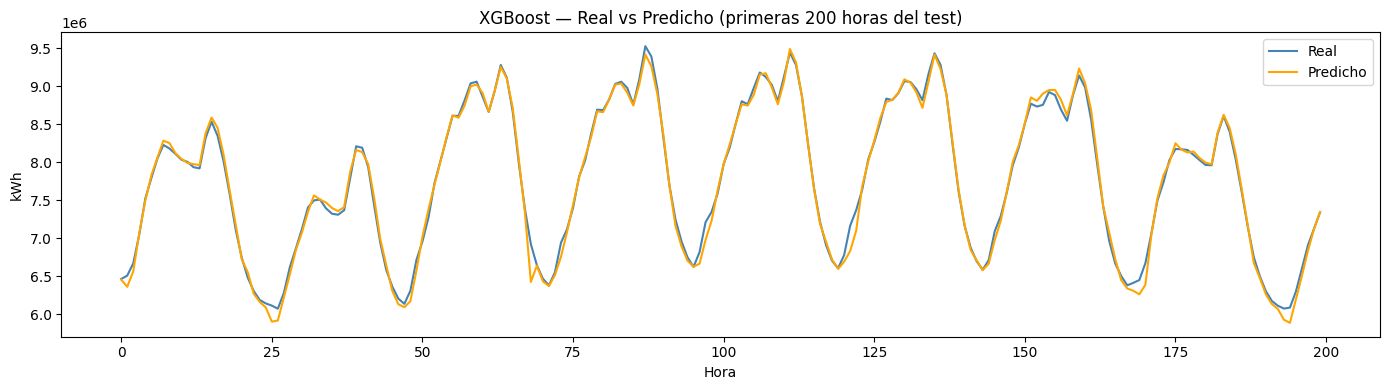

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:200], label='Real', color='steelblue')
plt.plot(y_pred[:200], label='Predicho', color='orange')
plt.legend()
plt.title('XGBoost — Real vs Predicho (primeras 200 horas del test)')
plt.xlabel('Hora')
plt.ylabel('kWh')
plt.tight_layout()
plt.show()

### 2.7 Importancia de características

XGBoost permite inspeccionar qué variables tuvieron mayor peso en las predicciones:

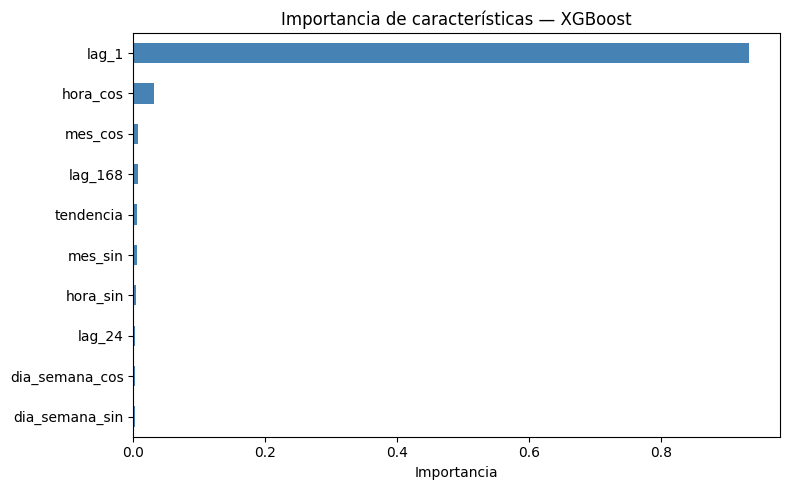

In [8]:
importancias = pd.Series(model.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias.plot(kind='barh', color='steelblue')
plt.title('Importancia de características — XGBoost')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

### 2.8 Limitación: dependencia de lags

Los lags requieren valores reales históricos. En producción, predecir 1 hora adelante es directo, pero para horizontes largos (días, semanas) los lags deben alimentarse con predicciones previas, acumulando error. Para predicción de largo plazo se requiere un modelo diferente.

---
## 3. Modelo Prophet (Largo Plazo)

Prophet es un modelo estadístico de descomposición de series de tiempo desarrollado por Meta. Modela la serie como la suma de tres componentes:

- **Tendencia:** crecimiento o decrecimiento estructural a largo plazo.
- **Estacionalidad:** patrones repetitivos a nivel diario, semanal y anual.
- **Festividades:** efectos de días especiales (opcional).

A diferencia de XGBoost, Prophet **no requiere lags**, por lo que puede proyectar cualquier horizonte futuro directamente. Es el modelo elegido para planeación de mediano y largo plazo del sistema eléctrico.

**Caso de uso:** predicción de la demanda a días o semanas adelante para planeación estratégica.

### 3.1 Carga y preparación de datos

Prophet requiere exactamente dos columnas: `ds` (fecha) e `y` (valor).

In [9]:
from prophet import Prophet

dataProphet = pd.read_csv('../../src/data/raw/preprocesamiento_demanda_colombia_filtrado_agg_hora.csv')

dataProphet = (
    dataProphet
    .copy()
    .drop(columns=[x for x in dataProphet.columns if x != 'FechaHora' and x != 'Valor'])
    .rename(columns={'FechaHora': 'ds', 'Valor': 'y'})
)

print(f'Filas: {len(dataProphet)}')
dataProphet.head()

D:\5_Universidad\ProyectoMetodologiasAgiles\tdsp_template\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filas: 17544


,ds,y
0,2024-01-01 00:00:00,6184439.03
1,2024-01-01 01:00:00,6065207.49
2,2024-01-01 02:00:00,5986090.73
3,2024-01-01 03:00:00,5857732.74
4,2024-01-01 04:00:00,5751376.10


### 3.2 Entrenamiento

Se activan las estacionalidades diaria, semanal y anual para capturar los patrones cíclicos de la demanda energética.

In [10]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

model_prophet.fit(dataProphet)

20:55:34 - cmdstanpy - INFO - Chain [1] start processing
20:55:41 - cmdstanpy - INFO - Chain [1] done processing


### 3.3 Predicción a 30 días

Se genera una proyección de 30 días hacia adelante (720 horas) sin necesidad de datos reales intermedios:

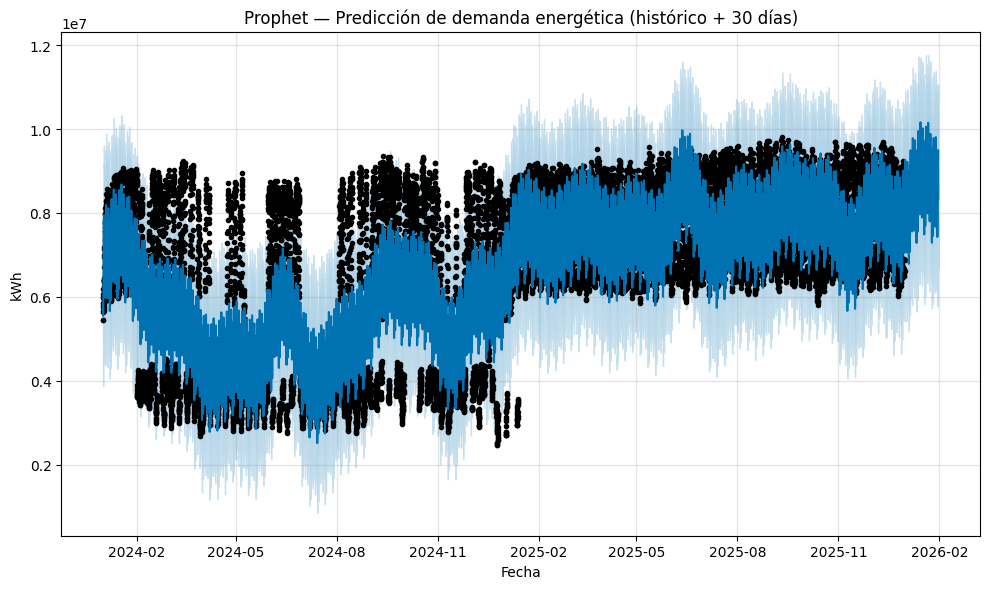

In [11]:
futuro = model_prophet.make_future_dataframe(periods=30*24, freq='h')
forecast = model_prophet.predict(futuro)

fig = model_prophet.plot(forecast)
plt.title('Prophet — Predicción de demanda energética (histórico + 30 días)')
plt.xlabel('Fecha')
plt.ylabel('kWh')
plt.tight_layout()
plt.show()

La gráfica muestra los datos históricos (puntos) junto con la predicción (línea) y el intervalo de confianza (área sombreada). El modelo continúa correctamente los patrones cíclicos y la tendencia.

### 3.4 Validación cruzada temporal

Prophet incluye una utilidad de validación cruzada temporal que simula predicciones en distintos puntos del tiempo:

- `initial`: período de entrenamiento inicial.
- `period`: cada cuánto se genera un nuevo punto de corte.
- `horizon`: horizonte de predicción evaluado.

In [12]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    model_prophet,
    initial='600 days',
    period='30 days',
    horizon='30 days'
)

df_metrics = performance_metrics(df_cv)
print(df_metrics[['horizon', 'mae', 'rmse', 'mape']].head(10))

  0%|          | 0/4 [00:00<?, ?it/s]20:55:45 - cmdstanpy - INFO - Chain [1] start processing
20:55:48 - cmdstanpy - INFO - Chain [1] done processing
 25%|██▌       | 1/4 [00:04<00:14,  4.90s/it]20:55:50 - cmdstanpy - INFO - Chain [1] start processing
20:55:53 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:09<00:09,  4.89s/it]20:55:54 - cmdstanpy - INFO - Chain [1] start processing
20:55:58 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 3/4 [00:14<00:04,  4.70s/it]20:55:59 - cmdstanpy - INFO - Chain [1] start processing
20:56:07 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 4/4 [00:23<00:00,  5.96s/it]


          horizon           mae          rmse      mape
0 3 days 00:00:00  9.885983e+05  1.144970e+06  0.127382
1 3 days 01:00:00  9.908489e+05  1.146097e+06  0.127699
2 3 days 02:00:00  9.929316e+05  1.147413e+06  0.128012
3 3 days 03:00:00  9.943470e+05  1.148844e+06  0.128236
4 3 days 04:00:00  9.952982e+05  1.150586e+06  0.128387
5 3 days 05:00:00  9.979861e+05  1.153642e+06  0.128783
6 3 days 06:00:00  1.002194e+06  1.159532e+06  0.129375
7 3 days 07:00:00  1.007314e+06  1.166105e+06  0.130070
8 3 days 08:00:00  1.013048e+06  1.172762e+06  0.130808
9 3 days 09:00:00  1.018609e+06  1.178856e+06  0.131461


El MAPE de ~12.7% a 3 días representa un error aceptable para planeación estratégica del sistema eléctrico. El error crece gradualmente con el horizonte, lo que es esperado en modelos de largo plazo.

---
## 4. Comparación de modelos

| Modelo | MAE (kWh) | RMSE (kWh) | R² | Horizonte recomendado |
|--------|-----------|------------|-----|-----------------------|
| XGBoost + lags | 76,343 | 113,253 | 0.9864 | Corto plazo (1 hora) |
| Prophet | ~990,000 | ~1,144,970 | — | Largo plazo (días/semanas) |

Ambos modelos son complementarios:

- **XGBoost** es superior en precisión absoluta para predicción horaria operativa (error < 1% del valor típico de demanda).
- **Prophet** permite proyecciones de mediano plazo sin depender de datos reales intermedios, siendo adecuado para planeación estratégica.
